In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number_1: int
    number_2: int
    number_3: int
    number_4: int
    operation_1: str
    operation_2: str
    final_number_1: int
    final_number_2: int

In [3]:
def add_node_1(state: AgentState) -> AgentState:
    state['final_number_1'] = state['number_1'] + state['number_2']
    return state

def add_node_2(state: AgentState) -> AgentState:
    state['final_number_2'] = state['number_3'] + state['number_4']
    return state

def subtract_node_1(state: AgentState) -> AgentState:
    state['final_number_1'] = state['number_1'] - state['number_2']
    return state

def subtract_node_2(state: AgentState) -> AgentState:
    state['final_number_2'] = state['number_3'] - state['number_4']
    return state

def router_node_1(state: AgentState) -> AgentState:
    if state['operation_1'] == '+':
        return 'addition'
    elif state['operation_1'] == '-':
        return 'subtraction'
    else:
        raise ValueError("Invalid operation")
    
def router_node_2(state: AgentState) -> AgentState:
    if state['operation_2'] == '+':
        return 'addition'
    elif state['operation_2'] == '-':
        return 'subtraction'
    else:
        raise ValueError("Invalid operation")



In [7]:
graph = StateGraph(AgentState)

graph.add_node("add_node_1", add_node_1)
graph.add_node("add_node_2", add_node_2)
graph.add_node("subtract_node_1", subtract_node_1)
graph.add_node("subtract_node_2", subtract_node_2)
graph.add_node("router_node_1", lambda state: state)
graph.add_node("router_node_2", lambda state: state)

graph.add_edge(START, "router_node_1")
graph.add_conditional_edges(
    "router_node_1",
    router_node_1,
    {
        "addition": "add_node_1",
        "subtraction": "subtract_node_1"
    }
)
graph.add_edge("add_node_1", "router_node_2")
graph.add_edge("subtract_node_1", "router_node_2")

graph.add_conditional_edges(
    "router_node_2",
    router_node_2,
    {
        "addition": "add_node_2",
        "subtraction": "subtract_node_2"
    }
)

graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)

app = graph.compile()


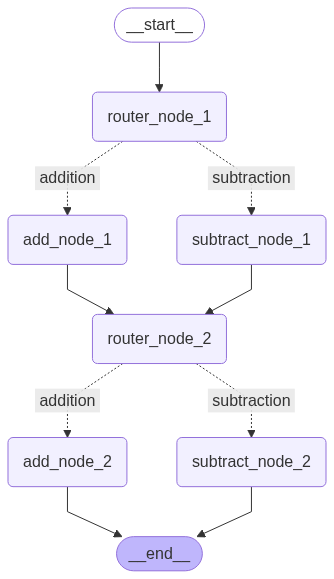

In [8]:
app

In [9]:
answer = app.invoke(AgentState(
    number_1=10,
    number_2=5,
    number_3=20,
    number_4=15,
    operation_1='+',
    operation_2='-',
    final_number_1=0,
    final_number_2=0
))

In [10]:
answer

{'number_1': 10,
 'number_2': 5,
 'number_3': 20,
 'number_4': 15,
 'operation_1': '+',
 'operation_2': '-',
 'final_number_1': 15,
 'final_number_2': 5}